# WP4 Annex A, Level 1: the stratigraphic frame, checked basis piece by basis piece

Annex A of the WP4 period-prior guideline builds the sediment-hosted sampler in five levels and closes each level with a "Basis:" sentence naming the documents the level may draw on. For Level 1, the stratigraphic frame, that sentence is *"the SA Geological Survey 1:250,000 sheets and explanatory notes for the Andamooka and Torrens areas and the logged t0 bores."* It names three pieces, and this notebook takes them one at a time:

- **Part A: the 1:250,000 sheets** (ANDAMOOKA 1966, TORRENS 1964, first editions).
- **Part B: the explanatory notes.** No notes booklet was issued for either sheet; the companion text is Johns' "Geology and mineral resources of the Andamooka-Torrens area", RB 61/00102 (1965) published as Bulletin 41 (1968).
- **Part C: the logged t0 bores** (the SA Geodata export clipped to the study windows and to a 2 degree buffer, with the 1979 SADME compilation as a cross-check).

Each part ends with a verdict on that piece: on disk or not, in state at t0 or not, and what it contributes to the frame. Part D puts the three together. Only files in `wp4_prior_state/annexA_levels/level1_stratigraphic_frame/` are read. The information-state rule is one cutoff, t0 = 2 May 1975 (the EL 190 grant); anything later is labelled and used only to check the modern export against the period record. Figures are drawn at final printed width and saved at 300 dpi to `03_results/wp4_prior/figures/` as `wp4_L1_<part><step>_*.png`.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

All reads are relative paths into the Level 1 folder. The cell lists the folder and loads the tables. Dates in the bore tables are the hole's own drill date (`MAX_DRILLED_DEPTH_DATE` in SA Geodata); membership at t0 is a date screen, not a stored flag.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

L1 = Path("../../01_data/wp1_data/database/wp4_prior_state/annexA_levels/level1_stratigraphic_frame")
FIG = Path("../../03_results/wp4_prior/figures")
assert L1.is_dir(), "run from 02_code/notebooks/"
FIG.mkdir(parents=True, exist_ok=True)

T0 = pd.Timestamp("1975-05-02")                       # EL 190 grant: the one cutoff
OD_LON, OD_LAT = 136.887, -30.441                     # Olympic Dam (wp1_harvester OD_CENTER)
FT = 0.3048

for p in sorted(L1.rglob("*")):
    if p.is_file():
        print(f"{p.stat().st_size/1e6:8.2f} MB  {p.relative_to(L1)}")

win = pd.read_csv(L1 / "bores/study_windows.csv").set_index("window")
reg = pd.read_csv(L1 / "bores/bores_regional_window.csv", parse_dates=["drill_date"])
comp = pd.read_csv(L1 / "bores/bores_companion_window.csv", parse_dates=["drill_date"])
base = pd.read_csv(L1 / "bores/bores_buffer2deg_pre_t0_basement.csv", parse_dates=["drill_date"])
iv = pd.read_csv(L1 / "bores/bores_buffer2deg_pre_t0_basement_strat_intervals.csv")
sp = pd.read_csv(L1 / "bores/bores_buffer2deg_pre_t0_strat_petroleum.csv", parse_dates=["drill_date"])
bull = (L1 / "notes/Bull_041_Johns_1968_text.txt").read_text(encoding="utf-8", errors="replace").splitlines()

reg_t0 = reg[reg.drill_date < T0]
print(f"\nregional window: {len(reg)} holes, {reg.drill_date.notna().sum()} dated, {len(reg_t0)} before t0")
print(f"2 degree buffer, before t0, logged pre-Adelaidean rock: {len(base)}; stratigraphic/petroleum class: {len(sp)}")
print(f"Bulletin 41 text: {len(bull)} lines")


    0.00 MB  README.md
    0.01 MB  bores/bores_buffer2deg_findings.md
    0.12 MB  bores/bores_buffer2deg_pre_t0_basement.csv
    0.11 MB  bores/bores_buffer2deg_pre_t0_basement_strat_intervals.csv
    0.03 MB  bores/bores_buffer2deg_pre_t0_strat_petroleum.csv
    0.18 MB  bores/bores_companion_window.csv
    0.08 MB  bores/bores_companion_window_strat_intervals.csv
    0.15 MB  bores/bores_regional_window.csv
    0.05 MB  bores/bores_regional_window_strat_intervals.csv
    0.00 MB  bores/dh_bulk_manifest.csv
    0.00 MB  bores/study_windows.csv
    6.01 MB  crosscheck_mesac17946/SADME Stuart Shelf Project. Drillhole stratigraphy compilation_ using data acquired until 31_12_1978. _Draft only_
    6.01 MB  crosscheck_mesac17946/mesac17946_ENV09395.pdf
    0.22 MB  crosscheck_mesac17946/mesac17946_ENV09395_ocr.txt
   16.19 MB  notes/Bull 041 Geology and Mineral Resources of the Andamooka and Torrens Area.pdf
    0.49 MB  notes/Bull_041_Johns_1968_text.txt
   24.23 MB  notes/RB 61_00102 


regional window: 1263 holes, 1046 dated, 101 before t0
2 degree buffer, before t0, logged pre-Adelaidean rock: 347; stratigraphic/petroleum class: 110
Bulletin 41 text: 6343 lines


## Step 0. Before the pieces: what Level 1 holds and when it dates from

Before any number is used, the sources are placed on a time axis against t0. The two sheets carry their edition years on their margins; the Johns text has a report-book date and a Bulletin transmittal date; the bores carry drill dates; the SADME compilation is dated 1979 and is the one item that post-dates t0. The bars count the regional-window holes by drill year, which shows how thin the bore record is before the licence was granted and how the WMC drilling floods in after it.


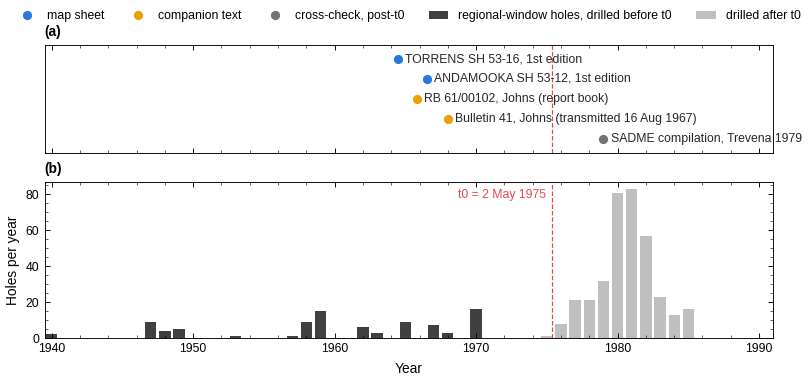

regional-window holes dated 1940-1985: 446; before t0: 101 (first 1925-06-26, last 1970-12-12); undated: 217
holes per year, 1970-1978: {1970: 16, 1975: 1, 1976: 8, 1977: 21, 1978: 21}


In [3]:
docs = [   # label, date, kind; dates from the sheet margins, the SARIG record date, the Bulletin transmittal and the compilation cover
    ("TORRENS SH 53-16, 1st edition", "1964-07-01", "sheet"),
    ("ANDAMOOKA SH 53-12, 1st edition", "1966-07-01", "sheet"),
    ("RB 61/00102, Johns (report book)", "1965-10-19", "text"),
    ("Bulletin 41, Johns (transmitted 16 Aug 1967)", "1968-01-01", "text"),
    ("SADME compilation, Trevena 1979", "1979-01-01", "crosscheck"),
]
docs = pd.DataFrame(docs, columns=["label", "date", "kind"])
docs["date"] = pd.to_datetime(docs.date)
KIND_COL = {"sheet": "#2a78d6", "text": "#eda100", "crosscheck": "0.45"}

def dec_year(ts):
    return ts.year + (ts.dayofyear - 1) / 365.25
docs["year"] = docs.date.map(dec_year)
T0Y = dec_year(T0)

yr = reg.drill_date.dropna().dt.year.astype(int)
counts = yr.value_counts().sort_index()
counts = counts[(counts.index >= 1940) & (counts.index <= 1985)]
pre = counts[counts.index < T0.year]
post = counts[counts.index >= T0.year]

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(COL2, 3.6), sharex=True,
                               gridspec_kw={"height_ratios": [1.1, 1.6]})
fig.subplots_adjust(hspace=0.22, left=0.07, right=0.99, top=0.86, bottom=0.12)
for i, r in docs.iterrows():
    ax0.plot(r.year, i, marker="o", ls="", color=KIND_COL[r.kind], ms=5)
    ax0.text(r.year + 0.5, i, r.label, va="center", color="0.15")
ax0.set_yticks(range(len(docs))); ax0.set_yticklabels([]); ax0.set_ylim(-0.7, len(docs) - 0.3)
ax0.yaxis.set_minor_locator(plt.NullLocator())
ax0.tick_params(axis="y", length=0)
ax0.invert_yaxis()
ax1.bar(pre.index, pre.values, width=0.8, color="0.25", label="regional-window holes, drilled before t0")
ax1.bar(post.index, post.values, width=0.8, color="0.75", label="drilled after t0")
for ax in (ax0, ax1):
    ax.axvline(T0Y, color="#e34948", lw=0.8, ls="--")
ax1.text(T0Y - 0.4, ax1.get_ylim()[1] * 0.95, "t0 = 2 May 1975", color="#e34948", va="top", ha="right")
ax1.set_ylabel("Holes per year"); ax1.set_xlabel("Year")
ax1.set_xlim(1939.5, 1991)
handles = [plt.Line2D([], [], marker="o", ls="", color=KIND_COL[k], ms=5, label=lab)
           for k, lab in [("sheet", "map sheet"), ("text", "companion text"), ("crosscheck", "cross-check, post-t0")]]
h1, l1 = ax1.get_legend_handles_labels()
ax0.legend(handles=handles + h1, loc="lower center", bbox_to_anchor=(0.5, 1.12), ncol=5)
panel_labels((ax0, ax1))
fig.savefig(FIG / "wp4_L1_00_information_state.png", dpi=300)
plt.show()

print(f"regional-window holes dated 1940-1985: {int(counts.sum())}; before t0: {len(reg_t0)} "
      f"(first {reg_t0.drill_date.min().date()}, last {reg_t0.drill_date.max().date()}); undated: {int(reg.drill_date.isna().sum())}")
print("holes per year, 1970-1978:", {int(k): int(v) for k, v in counts[(counts.index >= 1970) & (counts.index <= 1978)].items()})


### How to read this figure

Panel (a) puts each Level 1 source at its date: blue dots are the two map sheets, orange the companion text in its two forms, grey the 1979 SADME compilation. Panel (b) counts the holes in the regional window by drill year; dark bars are holes drilled before the red dashed line (t0, 2 May 1975), light bars after it. The sheets and the text all sit before t0, so the whole frame side of Level 1 is in state. The bore record before t0 is thin, a handful of holes in most years, and it jumps after 1975 when WMC's RD series begins; those later holes are exactly the ones the prior must not see. The compilation sits four years after t0 and is used only in Step C3, to check the modern export against a period reading.


## Part A, basis piece 1: the 1:250,000 sheets

### Step A1. The two sheets, the study windows and the deposit

The first editions are shown as their 150 dpi renders, placed in longitude and latitude from the neat lines of each sheet (ANDAMOOKA 136.5 to 138 E, 30 to 31 S; TORRENS the same longitudes, 31 to 32 S). The neat-line pixels were read from the graticule corners of each render and are checked here by the pixels-per-degree they imply against the sheet scale. The regional window and the deposit go on ANDAMOOKA, the companion window on TORRENS. This is the frame's only map view of the surface geology at the deposit before drilling.


ANDAMOOKA 1966: 2266 px/deg lon, 2631 px/deg lat; expected at 1:250,000 and 150 dpi: 2266 and 2630


TORRENS 1964: 2253 px/deg lon, 2626 px/deg lat; expected at 1:250,000 and 150 dpi: 2242 and 2630


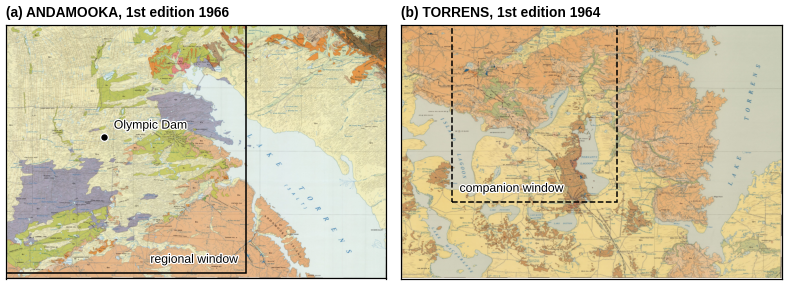

deposit at 136.887 E, -30.441 S; regional window 136.3-137.45 E, -30.98--29.92 S (its western 0.2 degree lies off the ANDAMOOKA sheet); companion window 136.7-137.35 E, -31.7--31.0 S


In [4]:
SHEETS = {   # file, (left, right, top, bottom) neat-line pixels, lon/lat extent of the neat lines
    "ANDAMOOKA 1966": ("sheets/andamooka_1966_first_edition_150dpi.jpg", (645, 4044, 417, 3048), (136.5, 138.0, -31.0, -30.0)),
    "TORRENS 1964":   ("sheets/torrens_1964_first_edition_150dpi.jpg",   (714, 4093, 420, 3046), (136.5, 138.0, -32.0, -31.0)),
}
STEP = 3   # render downsampling for display

def sheet_extent(name):
    file, px, geo = SHEETS[name]
    L, R, T, B = px; lon0, lon1, lat0, lat1 = geo
    im = Image.open(L1 / file); W, H = im.size
    ppd_x = (R - L) / (lon1 - lon0); ppd_y = (B - T) / (lat1 - lat0)
    return (lon0 - L / ppd_x, lon0 + (W - L) / ppd_x, lat1 - (H - T) / ppd_y, lat1 + T / ppd_y), ppd_x, ppd_y, im

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.9))
fig.subplots_adjust(wspace=0.04, left=0.01, right=0.99, top=0.9, bottom=0.02)
for ax, name in zip(axes, SHEETS):
    geo = SHEETS[name][2]
    ext, ppd_x, ppd_y, im = sheet_extent(name)
    arr = np.asarray(im.reduce(STEP))
    ax.imshow(arr, extent=ext, interpolation="antialiased")
    ax.set_xlim(geo[0], geo[1]); ax.set_ylim(geo[2], geo[3])
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_linewidth(0.8)
    lat_mid = 0.5 * (geo[2] + geo[3])
    print(f"{name}: {ppd_x:.0f} px/deg lon, {ppd_y:.0f} px/deg lat; expected at 1:250,000 and 150 dpi: "
          f"{111.32*np.cos(np.radians(lat_mid))*1e5/2.54/250000*150*1:.0f} and {111.32*1e5/2.54/250000*150:.0f}")
w = win.loc["regional"]
axes[0].add_patch(plt.Rectangle((w.lon_min, w.lat_min), w.lon_max - w.lon_min, w.lat_max - w.lat_min,
                                fill=False, ec="black", lw=1.0))
axes[0].text(w.lon_max - 0.03, w.lat_min + 0.03, "regional window", color="black", path_effects=HALO, va="bottom", ha="right")
axes[0].plot(OD_LON, OD_LAT, "o", color="black", ms=5, mec="white", mew=0.8)
axes[0].text(OD_LON + 0.04, OD_LAT + 0.02, "Olympic Dam", color="black", path_effects=HALO, va="bottom")
c = win.loc["companion"]
axes[1].add_patch(plt.Rectangle((c.lon_min, c.lat_min), c.lon_max - c.lon_min, c.lat_max - c.lat_min,
                                fill=False, ec="black", lw=1.0, ls="--"))
axes[1].text(c.lon_min + 0.03, c.lat_min + 0.03, "companion window", color="black", path_effects=HALO, va="bottom")
panel_labels(axes, ("(a) ANDAMOOKA, 1st edition 1966", "(b) TORRENS, 1st edition 1964"))
fig.savefig(FIG / "wp4_L1_A1_sheets_windows.png", dpi=300)
plt.show()
print(f"deposit at {OD_LON} E, {OD_LAT} S; regional window {w.lon_min}-{w.lon_max} E, {w.lat_min}-{w.lat_max} S "
      f"(its western 0.2 degree lies off the ANDAMOOKA sheet); companion window {c.lon_min}-{c.lon_max} E, {c.lat_min}-{c.lat_max} S")


### How to read this figure

Each panel is one first-edition sheet as printed, cropped to its neat lines, so the colours and the reference are the surveyor's own. In (a) the black dot is Olympic Dam and the solid rectangle the regional window that the bore tables were clipped to; its western strip falls off the sheet onto KINGOONYA. In (b) the dashed rectangle is the companion window over the Mount Gunson district. The printed check confirms the placement: the renders give 2,266 (ANDAMOOKA) and 2,253 (TORRENS) pixels per degree of longitude and about 2,630 per degree of latitude, within half a percent of what a 1:250,000 sheet at 150 dpi should give at these latitudes. What the reader should see is that the deposit sits on flat cover, sand ridges over the Arcoona plateau, with no outcrop of anything older than the Adelaidean shelf sediments anywhere on the sheet; the frame below the surface has to come from the text and the bores, not from mapped geology.


### Step A2. What the ANDAMOOKA sheet shows at the deposit

A 60 by 42 km crop of the 1966 render centred on the deposit, at the sheet's own colours and lettering. The deposit is placed through the graticule (the same neat-line pixels as Step A1). This is the surface geology an explorer could read off the published map before any hole was drilled in the window.


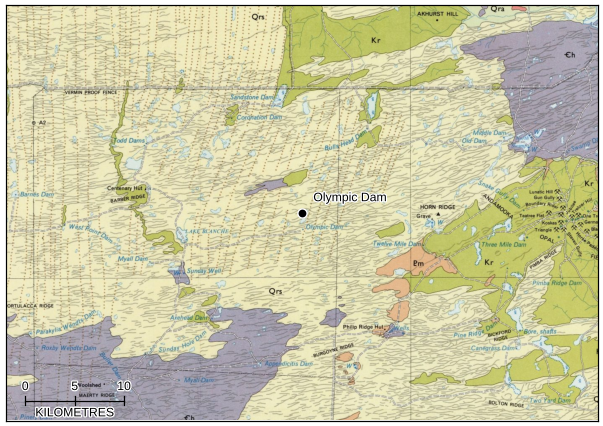

deposit at render pixel (1522, 1577); crop 1417 x 993 px = 60 x 42 km at 23.6 px/km


In [5]:
name = "ANDAMOOKA 1966"
file, px, geo = SHEETS[name]
ext, ppd_x, ppd_y, im = sheet_extent(name)
L, R, T, B = px; lon0, lon1, lat0, lat1 = geo
half_w_km, half_h_km = 30.0, 21.0
km_deg_lon = 111.32 * np.cos(np.radians(OD_LAT))
dlon, dlat = half_w_km / km_deg_lon, half_h_km / 111.32
def to_px(lon, lat):
    return L + (lon - lon0) * ppd_x, T + (lat1 - lat) * ppd_y
x0, y1 = to_px(OD_LON - dlon, OD_LAT - dlat)
x1, y0 = to_px(OD_LON + dlon, OD_LAT + dlat)
crop = im.crop((int(x0), int(y0), int(x1), int(y1)))

fig, ax = plt.subplots(figsize=(COL15, COL15 * (2 * half_h_km) / (2 * half_w_km) + 0.1))
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
ax.imshow(np.asarray(crop), extent=(OD_LON - dlon, OD_LON + dlon, OD_LAT - dlat, OD_LAT + dlat), interpolation="antialiased")
ax.set_aspect(1 / np.cos(np.radians(OD_LAT)))
ax.plot(OD_LON, OD_LAT, "o", color="black", ms=6, mec="white", mew=0.9)
ax.text(OD_LON + 0.012, OD_LAT + 0.008, "Olympic Dam", color="black", path_effects=HALO, va="bottom")
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
for sp_ in ax.spines.values(): sp_.set_linewidth(0.8)
sx, sy = OD_LON - dlon + 2 / km_deg_lon, OD_LAT - dlat + 2 / 111.32
for k in (0, 5, 10):
    ax.plot([sx + k / km_deg_lon] * 2, [sy - 0.004, sy + 0.004], color="black", lw=0.8)
    ax.text(sx + k / km_deg_lon, sy + 0.007, str(k), ha="center", va="bottom", path_effects=HALO)
ax.plot([sx, sx + 10 / km_deg_lon], [sy, sy], color="black", lw=0.8)
ax.text(sx + 5 / km_deg_lon, sy - 0.006, "KILOMETRES", ha="center", va="top", path_effects=HALO)
fig.savefig(FIG / "wp4_L1_A2_sheet_at_deposit.png", dpi=300)
plt.show()
ox, oy = to_px(OD_LON, OD_LAT)
print(f"deposit at render pixel ({ox:.0f}, {oy:.0f}); crop {crop.size[0]} x {crop.size[1]} px = {2*half_w_km:.0f} x {2*half_h_km:.0f} km at {ppd_x/km_deg_lon:.1f} px/km")


### How to read this figure

The picture is the ANDAMOOKA first edition itself, 60 km wide and 42 km high around the black dot that marks Olympic Dam, with a 10 km scale bar in the lower left. The pale yellow with fine ridging is Quaternary sand (Qrs on the sheet), the green patches are Cretaceous (Kr), the purple areas lettered Єh are the Cambrian Andamooka Limestone, and the orange patch lettered Pm south-east of the deposit is Upper Proterozoic, the Tent Hill Formation. The lettering and symbols are the surveyor's. What the reader should see is the absence: no unit older than the Adelaidean shelf sequence is mapped anywhere in the crop, no fault or fold symbol is drawn at the deposit, and nothing on the face gives a depth. The sheet locates the deposit on flat cover and hands every question about what lies beneath to the text and the bores.


### Verdict on basis piece 1: the sheets

On disk: yes, both first editions with renders, in `sheets/`. In state: yes, TORRENS 1964 and ANDAMOOKA 1966, eleven and nine years before t0. Contribution to the frame: the surface picture only. At the deposit the sheet shows sand and Cretaceous remnants over Cambrian limestone and the Tent Hill Formation, no basement and no structure; the regional window sits almost entirely on the ANDAMOOKA sheet and its western strip on KINGOONYA, which is not in the basis. The sheets fix the top of the frame and say nothing about its base; the placeholder band, the unconformity and its relief all have to come from Parts B and C.


## Part B, basis piece 2: the explanatory notes

No explanatory-notes booklet exists for either sheet (SARIG's ExpNotes series was walked in order and has no ANDAMOOKA or TORRENS entry). The companion text is Johns' "Geology and mineral resources of the Andamooka-Torrens area", written as report book RB 61/00102 (19 October 1965) and published as Geological Survey Bulletin 41 (transmitted 16 August 1967, printed 1968). Both are in `notes/`; the Bulletin's OCR text is beside it and is what the cells below search.

### Step B1. The cover stack as the Bulletin describes it, unit by unit

Every thickness the Bulletin gives for a unit of the Stuart Shelf succession between the surface and the Pernatty Grit (the unit now called Pandurra Formation) is taken from the text with its page, converted from feet, and drawn as a range. The cell also prints the lines of the text file that carry each number, so each bar can be checked against the scan.


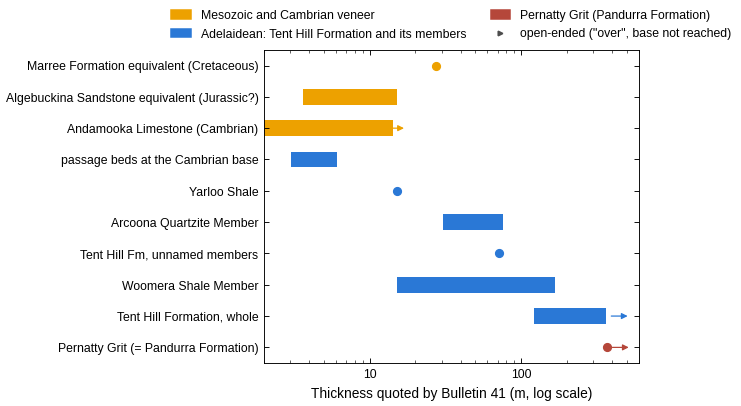

p. 34  Marree Formation equivalent (Cretaceous)           27 to     27 m    90 ft Mesozoic section at Yarrawurta Cliff  [line 1707]
p. 33  Algebuckina Sandstone equivalent (Jurassic?)        4 to     15 m    12 ft at Andamooka Opalfield; ~50 ft at Trig Bluff  [line 1101, line 1626, line 1631, line 2201]
p. 32  Andamooka Limestone (Cambrian)                      0 to     12 m +  veneer seldom > 40 ft on Andamooka, Roxby Downs, Parakylia; ~1,000 ft at Lake Arthur  [line 1532]
p. 31  passage beds at the Cambrian base                   3 to      6 m    10 to 20 ft  [line 1519]
p. 31  Yarloo Shale                                       15 to     15 m    50 ft at Tea Tree Creek  [line 1505]
p. 31  Arcoona Quartzite Member                           30 to     76 m    < 100 ft in the south to 250 ft at Woomera  [line 1478]
p. 29  Tent Hill Fm, unnamed members                      72 to     72 m    236 ft in Woomera No. 1  [line 1413]
p. 29  Woomera Shale Member                               15 t

In [6]:
# unit, low_ft, high_ft, open_top (True: text says "over"), where the figure comes from, Bulletin page, regex that finds the line
units = [
    ("Marree Formation equivalent (Cretaceous)",     90,   90,  False, "90 ft Mesozoic section at Yarrawurta Cliff",              34, r"90ft\. thick"),
    ("Algebuckina Sandstone equivalent (Jurassic?)", 12,   50,  False, "12 ft at Andamooka Opalfield; ~50 ft at Trig Bluff",      33, r"12ft\. in thickness|50ft\. of cross-bedded"),
    ("Andamooka Limestone (Cambrian)",               0,    40,  True,  "veneer seldom > 40 ft on Andamooka, Roxby Downs, Parakylia; ~1,000 ft at Lake Arthur", 32, r"seldom more than 40ft"),
    ("passage beds at the Cambrian base",            10,   20,  False, "10 to 20 ft",                                              31, r"10-20ft"),
    ("Yarloo Shale",                                 50,   50,  False, "50 ft at Tea Tree Creek",                                  31, r"50ft\. in thickness for which the name Yarloo"),
    ("Arcoona Quartzite Member",                     100,  250, False, "< 100 ft in the south to 250 ft at Woomera",              31, r"250ft\. in the Woomera"),
    ("Tent Hill Fm, unnamed members",                236,  236, False, "236 ft in Woomera No. 1",                                  29, r"236ft\. in thickness"),
    ("Woomera Shale Member",                         50,   548.5, False, "< 50 ft at Mount Gunson to 548.5 ft in Woomera No. 1",  29, r"548ft\. 6in\."),
    ("Tent Hill Formation, whole",                   400,  1200, True,  "400 to over 1,200 ft",                                    28, r"400ft\. to over 1,200ft"),
    ("Pernatty Grit (= Pandurra Formation)",         1220, 1220, True,  "1,220 ft penetrated in Woomera No. 1, base not reached",   25, r"I,220ft|1,220ft"),
]
ut = pd.DataFrame(units, columns=["unit", "low_ft", "high_ft", "open", "basis", "page", "pattern"])
ut["low_m"], ut["high_m"] = ut.low_ft * FT, ut.high_ft * FT

fig, ax = plt.subplots(figsize=(COL15, 3.9))
fig.subplots_adjust(left=0.36, right=0.98, top=0.86, bottom=0.13)
for i, r in ut.iterrows():
    col = "#eda100" if i < 3 else ("#2a78d6" if i < 9 else "#b5473a")
    if r.low_m == r.high_m:
        ax.plot(r.low_m, i, "o", color=col, ms=5)
    else:
        ax.barh(i, r.high_m - r.low_m, left=max(r.low_m, 2.0), height=0.5, color=col, lw=0)
    if r.open:
        ax.annotate("", xy=(r.high_m * 1.45, i), xytext=(r.high_m * 1.03, i), arrowprops=dict(arrowstyle="-|>", color=col, lw=0.8))
ax.set_yticks(range(len(ut))); ax.set_yticklabels(ut.unit); ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_ylim(len(ut) - 0.5, -0.5)
ax.set_xscale("log"); ax.set_xlim(2, 600); ax.set_xlabel("Thickness quoted by Bulletin 41 (m, log scale)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
handles = [plt.Rectangle((0, 0), 1, 1, color="#eda100", label="Mesozoic and Cambrian veneer"),
           plt.Rectangle((0, 0), 1, 1, color="#2a78d6", label="Adelaidean: Tent Hill Formation and its members"),
           plt.Rectangle((0, 0), 1, 1, color="#b5473a", label="Pernatty Grit (Pandurra Formation)"),
           plt.Line2D([], [], color="0.3", marker=">", ls="", label="open-ended (\"over\", base not reached)")]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.savefig(FIG / "wp4_L1_B1_bulletin_thicknesses.png", dpi=300)
plt.show()

for _, r in ut.iterrows():
    hits = [f"line {i+1}" for i, line in enumerate(bull) if re.search(r.pattern, line)]
    print(f"p. {r.page:>2}  {r.unit:<46s} {r.low_m:6.0f} to {r.high_m:6.0f} m{' +' if r.open else '  '}  {r.basis}  [{', '.join(hits) or 'NOT FOUND'}]")
stack_lo = ut.loc[ut.unit.isin(["Andamooka Limestone (Cambrian)", "Arcoona Quartzite Member", "Tent Hill Fm, unnamed members", "Woomera Shale Member"]), "low_m"].sum()
stack_hi = ut.loc[ut.unit.isin(["Andamooka Limestone (Cambrian)", "Arcoona Quartzite Member", "Tent Hill Fm, unnamed members", "Woomera Shale Member"]), "high_m"].sum()
print(f"\nsum of the member ranges, Andamooka Limestone to Woomera Shale: {stack_lo:.0f} to {stack_hi:.0f} m; the Bulletin's own whole-formation figure for the Tent Hill: {400*FT:.0f} to over {1200*FT:.0f} m")


### How to read this figure

Each row is one unit of the cover in the order it is met from the surface down, and the bar or dot is the thickness the Bulletin gives for it, in metres on a logarithmic axis so that a 3 m passage bed and a 370 m formation can share the picture. A dot is a single quoted value; a bar is the range between the thinnest and thickest occurrence the text names; an arrow means the text says "over" or that the base was not reached. Orange rows are the Mesozoic and Cambrian veneer, blue the Adelaidean Tent Hill Formation and its members, red the Pernatty Grit. The printed lines below the figure give the page and the line of the text file each number was read from. What the reader should see is where the Bulletin is specific and where it is not: the Cambrian limestone is a veneer of at most 12 m over the deposit's stations, the Arcoona Quartzite 30 to 76 m, the Woomera Shale up to 167 m in Woomera No. 1 but under 15 m over the Pernatty high at Mount Gunson, and the whole Tent Hill Formation 122 to over 366 m; summing the member ranges from the Andamooka Limestone to the Woomera Shale gives 118 to 328 m, consistent with the formation figure. The Pernatty Grit's own thickness is unknown, 372 m being penetrated without reaching its base, so the Bulletin bounds the cover above the Grit but not the depth to crystalline basement.


### Step B2. Woomera No. 1 bore, read in 1968 and read today

WOOMERA 1 (Clarence River Basin Oil, 1958, 611 m) is the one deep hole near the window, so it deserves its own step. Bulletin 41 (1968) logs it as unnamed siltstones to 236 ft, the Woomera Shale Member from 236 to 784.5 ft, and "Pernatty Grit" from 784.5 ft to the bottom, 1,220 ft penetrated without reaching its base; the modern SA Geodata log of the same hole puts Whyalla Sandstone and Tapley Hill Formation where the 1968 log had grit, and the Pandurra Formation from 454 m. Both columns are drawn to the same depth scale, with the 1979 compilation's reading (RL 460 ft, top Pandurra at -332 m, i.e. 472 m) as a line across both. The cell also prints the lines of the Bulletin text that carry the 1968 depths, as provenance.


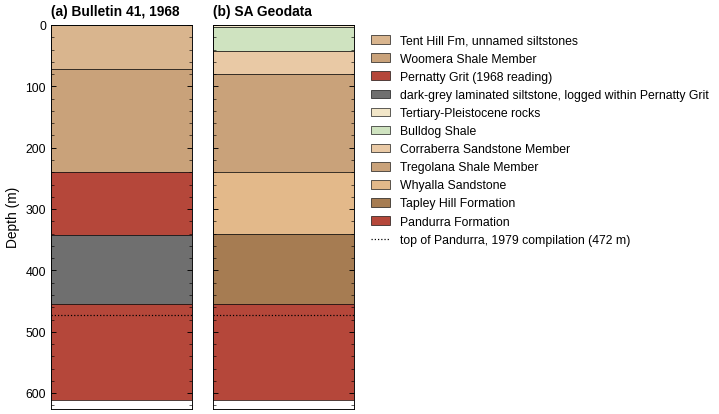

top of Pandurra equivalent: 1968 reading 239 m (784.5 ft); SA Geodata 454 m; 1979 compilation 472 m; end of hole 611 m

Bulletin 41 text lines carrying the 1968 depths:
  line 1183: 784t           1,066   Pink and purple grits, medium to coarse grained; quartz grains
  line 1382: Grit. In boring it was intersected between 236ft. and 784ft. 6in.
  line 1413: Woomer a No. 1 bore disclosed a section 236ft. in thickness below the succeeding
  line 5465: 784t-1,066 Pink-purple grits


In [7]:
# period log, Bulletin 41 pp. 25 and 29 (feet, converted); the dark-grey siltstone inside the 1968 "Pernatty Grit" is kept as its own band
period = [("Tent Hill Fm, unnamed siltstones", 0, 236), ("Woomera Shale Member", 236, 784.5),
          ("Pernatty Grit (1968 reading)", 784.5, 1122), ("dark-grey laminated siltstone, logged within Pernatty Grit", 1122, 1490),
          ("Pernatty Grit (1968 reading)", 1490, 2005)]
period = pd.DataFrame(period, columns=["unit", "from_ft", "to_ft"])
period["from_m"], period["to_m"] = period.from_ft * FT, period.to_ft * FT
modern = iv[iv.DH_NAME == "WOOMERA 1"].sort_values("DEPTH_FROM_M")
comp_rl_m, comp_top_pandurra_elev = 460 * FT, -332          # Trevena 1979, Appendix I, Torrens sheet 9 (handwritten, read from the scan)
comp_top_pandurra_m = comp_rl_m - comp_top_pandurra_elev

UNIT_COL = {"Tertiary-Pleistocene rocks": "#f2e6c8", "Bulldog Shale": "#cfe3c0", "Corraberra Sandstone Member": "#e9c9a5",
            "Tregolana Shale Member": "#c9a27a", "Whyalla Sandstone": "#e3b98a", "Tapley Hill Formation": "#a67c52",
            "Pandurra Formation": "#b5473a", "Tent Hill Fm, unnamed siltstones": "#d9b58e", "Woomera Shale Member": "#c9a27a",
            "Pernatty Grit (1968 reading)": "#b5473a", "dark-grey laminated siltstone, logged within Pernatty Grit": "#6f6f6f"}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(COL15, 4.2), sharey=True)
fig.subplots_adjust(left=0.1, right=0.6, top=0.93, bottom=0.1, wspace=0.15)
for ax, tab, f0, f1 in [(ax0, period, "from_m", "to_m"), (ax1, modern, "DEPTH_FROM_M", "DEPTH_TO_M")]:
    for _, r in tab.iterrows():
        u = r.unit if "unit" in tab.columns else r.STRAT_UNIT_NAME
        ax.add_patch(plt.Rectangle((0, r[f0]), 1, r[f1] - r[f0], color=UNIT_COL[u], ec="black", lw=0.4))
    ax.set_xlim(0, 1); ax.set_xticks([]); ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.axhline(comp_top_pandurra_m, color="black", ls=":", lw=0.8)
ax0.set_ylim(625, 0); ax0.set_ylabel("Depth (m)")
seen = {}
for u in list(period.unit) + list(modern.STRAT_UNIT_NAME):
    seen.setdefault(u, UNIT_COL[u])
handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec="black", lw=0.4, label=u) for u, c in seen.items()]
handles.append(plt.Line2D([], [], color="black", ls=":", lw=0.8, label=f"top of Pandurra, 1979 compilation ({comp_top_pandurra_m:.0f} m)"))
ax1.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.05, 1.0))
panel_labels((ax0, ax1), ("(a) Bulletin 41, 1968", "(b) SA Geodata"))
fig.savefig(FIG / "wp4_L1_B2_woomera1_columns.png", dpi=300)
plt.show()

p_top = period.loc[period.unit.str.startswith("Pernatty"), "from_m"].min()
m_top = modern.loc[modern.STRAT_UNIT_NAME == "Pandurra Formation", "DEPTH_FROM_M"].min()
print(f"top of Pandurra equivalent: 1968 reading {p_top:.0f} m (784.5 ft); SA Geodata {m_top:.0f} m; 1979 compilation {comp_top_pandurra_m:.0f} m; end of hole {period.to_m.max():.0f} m")
print("\nBulletin 41 text lines carrying the 1968 depths:")
for i, line in enumerate(bull):
    if re.search(r"236ft|784|1,220ft", line):
        print(f"  line {i+1}: {line.strip()}")


### How to read this figure

Both columns are the same hole, WOOMERA 1, drawn from surface (top) to its bottom at 611 m, with the depth axis shared. Column (a) is the log as Bulletin 41 printed it in 1968: siltstones of the Tent Hill Formation, then the Woomera Shale, then from 239 m everything is called Pernatty Grit, the unit that is now the Pandurra Formation, with a grey band for the 112 m of dark-grey laminated siltstone the 1968 log noted inside it. Column (b) is the modern SA Geodata log: Cretaceous Bulldog Shale, then the Adelaidean units in today's names, with the Whyalla Sandstone and Tapley Hill Formation occupying the interval the 1968 log called grit, and the Pandurra Formation only from 454 m. The dotted line is the 1979 compilation's reading, 472 m, on the modern side. The reader should take away that the period document places the base of the cover at this hole about 215 m shallower than the modern export does. Under the citation rule the frame's t0 value for this hole is the 1968 one, 239 m, and the modern 454 m is what a later explorer would have had; the notebook carries both, labelled. Step C3 tests whether such differences are reinterpretation or datum.


### Verdict on basis piece 2: the notes

On disk: yes, in both forms, RB 61/00102 (1965) and Bulletin 41 (1968), with searchable text. In state: yes, both before t0. Contribution to the frame: the only period thickness statements. The Bulletin gives the cover above the Pernatty Grit as 122 to over 366 m for the Tent Hill Formation with a Cambrian veneer of a few tens of metres, logs the one deep hole near the window with the Grit from 239 m (a reading that the modern export has since revised to 454 m, Step B2), reports the Woomera Shale thinning to under 15 m over a Pernatty high, and quotes the 1962 aeromagnetics as putting magnetic basement within 610 m on the Andamooka side. It does not give a thickness for the Grit, and it names no hole in the two map areas that reached crystalline basement. Two cautions for the citation table: the period stratigraphy differs from the modern one by reinterpretation, not datum, and the Bulletin's Pernatty Grit is treated in its own text as the base of the Adelaidean cover, not as basement.


## Part C, basis piece 3: the logged t0 bores

### Step C1. Where the t0 bores are, and what they reached

Three bore tables are combined on one map: the holes inside the regional window that were drilled before t0 (all of them bottom in cover), every stratigraphic- or petroleum-class hole drilled before t0 within the 2 degree buffer, and every hole in the buffer that logged pre-Adelaidean rock, split into those that reached crystalline basement and those that ended in the Pandurra Formation. The map is drawn in the published-plan convention: no numbered axes, a scale bar and north arrow instead. The point of the figure is the empty space around the deposit.


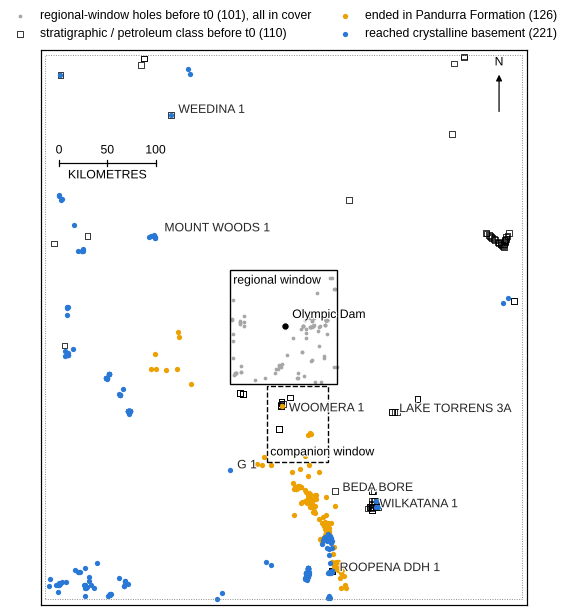

holes logging pre-Adelaidean rock before t0 in the buffer: 347 = 221 crystalline + 126 Pandurra only; inside the regional window: 0
nearest to the deposit: 82.5 km (WOOMERA 1); nearest crystalline basement: 159.6 km (G 1)
holes by 1:250,000 sheet: {'PORT AUGUSTA': 180, 'TORRENS': 37, 'GAIRDNER': 31, 'STREAKY BAY': 29, 'TARCOOLA': 26, 'YARDEA': 13, 'COOBER PEDY': 10, 'KINGOONYA': 8, 'BILLA KALINA': 7, 'WARRINA': 3, 'COPLEY': 2, 'MURLOOCOPPIE': 1}


In [8]:
CLS = {"crystalline": "#2a78d6", "pandurra": "#eda100"}
cry = base[base.reached_crystalline_basement]
pan = base[~base.reached_crystalline_basement]
w = win.loc["regional"]; c = win.loc["companion"]
buf = (w.lon_min - 2, w.lon_max + 2, w.lat_min - 2, w.lat_max + 2)
asp = 1 / np.cos(np.radians(OD_LAT))

fig, ax = plt.subplots(figsize=(COL15, 5.6))
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02)
ax.scatter(reg_t0.lon_dd, reg_t0.lat_dd, s=6, color="0.65", lw=0, label=f"regional-window holes before t0 ({len(reg_t0)}), all in cover")
ax.scatter(sp.lon_dd, sp.lat_dd, s=14, facecolor="none", edgecolor="black", lw=0.5, marker="s",
           label=f"stratigraphic / petroleum class before t0 ({len(sp)})")
ax.scatter(pan.lon_dd, pan.lat_dd, s=12, color=CLS["pandurra"], lw=0, label=f"ended in Pandurra Formation ({len(pan)})")
ax.scatter(cry.lon_dd, cry.lat_dd, s=12, color=CLS["crystalline"], lw=0, label=f"reached crystalline basement ({len(cry)})")
ax.add_patch(plt.Rectangle((w.lon_min, w.lat_min), w.lon_max - w.lon_min, w.lat_max - w.lat_min, fill=False, ec="black", lw=0.9))
ax.add_patch(plt.Rectangle((c.lon_min, c.lat_min), c.lon_max - c.lon_min, c.lat_max - c.lat_min, fill=False, ec="black", lw=0.9, ls="--"))
ax.add_patch(plt.Rectangle((buf[0], buf[2]), buf[1] - buf[0], buf[3] - buf[2], fill=False, ec="0.5", lw=0.6, ls=":"))
ax.plot(OD_LON, OD_LAT, "o", color="black", ms=5, mec="white", mew=0.8, zorder=5)
ax.text(OD_LON + 0.08, OD_LAT + 0.05, "Olympic Dam", va="bottom", path_effects=HALO)
for nm, dx, dy in [("WOOMERA 1", 0.08, -0.05), ("G 1", 0.08, 0.02), ("MOUNT WOODS 1", 0.1, 0.06), ("WEEDINA 1", 0.08, 0.02)]:
    r = base[base.DH_NAME == nm].iloc[0]
    ax.text(r.lon_dd + dx, r.lat_dd + dy, nm, color="0.15", path_effects=HALO, ha="left" if dx > 0 else "right")
for nm, dx, dy in [("WILKATANA 1", 0.08, 0.0), ("ROOPENA DDH 1", 0.08, 0.0), ("LAKE TORRENS 3A", 0.08, 0.0), ("BEDA BORE", 0.08, 0.0)]:
    r = sp[sp.DH_NAME == nm].iloc[0]
    ax.text(r.lon_dd + dx, r.lat_dd + dy, nm, color="0.15", path_effects=HALO)
ax.text(w.lon_min + 0.03, w.lat_max - 0.04, "regional window", va="top", path_effects=HALO)
ax.text(c.lon_min + 0.03, c.lat_min + 0.03, "companion window", va="bottom", path_effects=HALO)
ax.set_xlim(buf[0] - 0.05, buf[1] + 0.05); ax.set_ylim(buf[2] - 0.05, buf[3] + 0.05)
ax.set_aspect(asp)
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
for s in ax.spines.values(): s.set_linewidth(0.8)
# scale bar: 100 km in degrees of longitude at the deposit latitude
km_deg = 111.32 * np.cos(np.radians(OD_LAT))
x0, y0 = buf[0] + 0.15, buf[3] - 1.0
for k in (0, 50, 100):
    ax.plot([x0 + k / km_deg] * 2, [y0 - 0.03, y0 + 0.03], color="black", lw=0.8)
    ax.text(x0 + k / km_deg, y0 + 0.06, str(k), ha="center", va="bottom", path_effects=HALO)
ax.plot([x0, x0 + 100 / km_deg], [y0, y0], color="black", lw=0.8)
ax.text(x0 + 50 / km_deg, y0 - 0.06, "KILOMETRES", ha="center", va="top", path_effects=HALO)
ax.annotate("", xy=(buf[1] - 0.25, buf[3] - 0.15), xytext=(buf[1] - 0.25, buf[3] - 0.55),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=0.8))
ax.text(buf[1] - 0.25, buf[3] - 0.12, "N", ha="center", va="bottom", path_effects=HALO)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.savefig(FIG / "wp4_L1_C1_bore_map.png", dpi=300)
plt.show()

print(f"holes logging pre-Adelaidean rock before t0 in the buffer: {len(base)} = {len(cry)} crystalline + {len(pan)} Pandurra only; "
      f"inside the regional window: {int(base.in_regional_window.sum())}")
print(f"nearest to the deposit: {base.dist_od_km.min():.1f} km ({base.sort_values('dist_od_km').DH_NAME.iloc[0]}); "
      f"nearest crystalline basement: {cry.dist_od_km.min():.1f} km ({cry.sort_values('dist_od_km').DH_NAME.iloc[0]})")
print("holes by 1:250,000 sheet:", base.MAP_250000.str[7:].value_counts().to_dict())


### How to read this figure

The frame is the 2 degree buffer around the regional window (dotted outline), about 500 km across; the solid rectangle is the regional window with Olympic Dam as the black dot, the dashed one the companion window over Mount Gunson. Small grey dots are the 101 holes drilled in the regional window before t0, every one of which stopped in cover. Open squares are the 110 holes of stratigraphic or petroleum class drilled before t0 anywhere in the buffer; most are shallow engineering bores at Woomera and Lake Hart or the Wilkatana and Motpena petroleum wells far to the southeast. Orange dots are holes that reached the Pandurra Formation and stopped in it (126), blue dots holes that went into crystalline basement (221). What the reader should see is the empty ring: nothing orange or blue lies inside the window, the nearest orange dot is WOOMERA 1 at 82.5 km to the southwest, the orange cluster on the TORRENS sheet is the Mount Gunson and Pernatty drilling 110 to 170 km away, and the nearest blue dots are G 1 and the Mount Woods holes around 160 km away where the Gawler Craton comes to surface.


### Step C2. Depth to pre-Adelaidean rock against distance from the deposit

The same 347 holes are now read as constraints on cover thickness: the depth at which each first logged pre-Adelaidean rock, plotted against its distance from Olympic Dam. Depth increases downward so the plot reads as a section. The shaded band marks the distances inside which no such hole exists at t0.


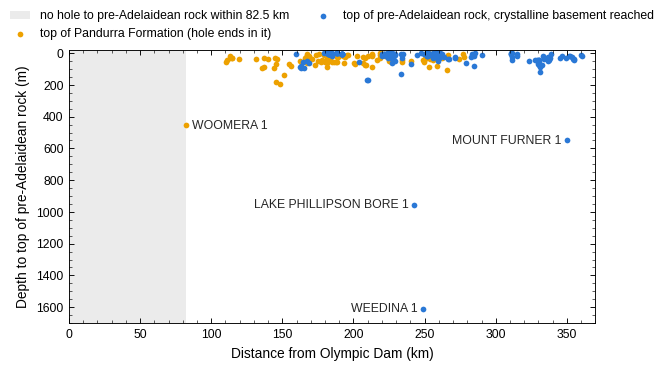

depth to top of pre-Adelaidean rock, all 347 holes: median 18 m, 90th percentile 65 m, max 1609 m
holes with that top deeper than 300 m:
               DH_NAME drill_date  dist_od_km  depth_top_pre_adelaidean_m first_pre_adelaidean_unit  max_depth_m
             WOOMERA 1 1958-05-30        82.5                      454.15        Pandurra Formation       611.12
LAKE PHILLIPSON BORE 1 1901-11-09       242.8                      957.00        Mulgathing Complex       963.47
             WEEDINA 1 1970-03-23       248.9                     1609.04   Archaean-Devonian rocks      1624.28
        MOUNT FURNER 1 1969-06-17       350.4                      548.64        Mulgathing Complex       555.04


In [9]:
fig, ax = plt.subplots(figsize=(COL15, 3.4))
fig.subplots_adjust(left=0.11, right=0.98, top=0.88, bottom=0.15)
near = base.dist_od_km.min()
ax.axvspan(0, near, color="0.92", lw=0, label=f"no hole to pre-Adelaidean rock within {near:.1f} km")
ax.scatter(pan.dist_od_km, pan.depth_top_pre_adelaidean_m, s=14, color=CLS["pandurra"], lw=0, label="top of Pandurra Formation (hole ends in it)")
ax.scatter(cry.dist_od_km, cry.depth_top_pre_adelaidean_m, s=14, color=CLS["crystalline"], lw=0, label="top of pre-Adelaidean rock, crystalline basement reached")
for nm, dx, dy, ha in [("WOOMERA 1", 4, 0, "left"), ("MOUNT FURNER 1", -4, 0, "right"),
                       ("LAKE PHILLIPSON BORE 1", -4, 0, "right"), ("WEEDINA 1", -4, 0, "right")]:
    r = base[base.DH_NAME == nm].iloc[0]
    ax.text(r.dist_od_km + dx, r.depth_top_pre_adelaidean_m + dy, nm, color="0.15", ha=ha, va="center")
ax.set_xlabel("Distance from Olympic Dam (km)"); ax.set_ylabel("Depth to top of pre-Adelaidean rock (m)")
ax.set_xlim(0, 370); ax.set_ylim(1700, -20)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.savefig(FIG / "wp4_L1_C2_depth_vs_distance.png", dpi=300)
plt.show()

q = base.depth_top_pre_adelaidean_m.describe()
print(f"depth to top of pre-Adelaidean rock, all {len(base)} holes: median {q['50%']:.0f} m, 90th percentile {base.depth_top_pre_adelaidean_m.quantile(0.9):.0f} m, max {q['max']:.0f} m")
print("holes with that top deeper than 300 m:")
print(base[base.depth_top_pre_adelaidean_m > 300][["DH_NAME", "drill_date", "dist_od_km", "depth_top_pre_adelaidean_m", "first_pre_adelaidean_unit", "max_depth_m"]]
      .sort_values("dist_od_km").to_string(index=False))


### How to read this figure

Each dot is one hole drilled before t0 that logged pre-Adelaidean rock; its position is how far it is from Olympic Dam (horizontal) and how deep the first pre-Adelaidean unit was met (vertical, deeper downward). Orange dots met the Pandurra Formation and stopped in it; blue dots went on into crystalline basement. The grey band covers the first 82.5 km, where there is no dot at all. Nearly all the dots sit above 100 m, because they are on the outcrop side of the shelf where the Pandurra or the craton is shallow. The few deep ones are far away: WOOMERA 1 (Pandurra at 454 m, 82.5 km, the modern reading of the log), MOUNT FURNER 1 (549 m, 350 km), LAKE PHILLIPSON BORE 1 (957 m, 243 km) and WEEDINA 1 (1,609 m, 249 km). The figure says in one picture what the frame has to live with: the only hole-derived cover thickness within 100 km of the deposit is a single point, and it is 82.5 km away.


### Step C3. Cross-check: the 1979 SADME compilation against the modern export

The compilation is post-t0 and is not a source for the frame, but it is a period reading of the same holes, so it tests whether the modern SA Geodata unit picks reproduce what SADME's geologists read in 1978. Its Torrens appendix gives, per hole, a reduced level and the elevation of the post-Pandurra cover surface; depth to top of Pandurra is their difference. Those values were read from the handwritten pages of the scan and are typed here with their page; the modern values come from the buffer table.


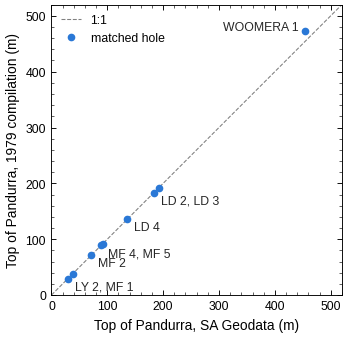

     hole  compilation_m  sa_geodata_m  page  difference_m
     LD 2            183        183.46    43         -0.46
     LD 3            192        191.72    43          0.28
     LD 4            136        135.27    43          0.73
     MF 1             38         38.00    42          0.00
     MF 2             71         71.00    42          0.00
     MF 4             89         89.00    42          0.00
     MF 5             92         92.00    42          0.00
     LY 2             29         29.40    46         -0.40
WOOMERA 1            472        454.15    48         17.85

holes agreeing within 1 m: 8 of 9; largest difference 18 m (WOOMERA 1)


In [10]:
# Trevena 1979 Appendix I (TORRENS): (RL m, elevation of top of Pandurra m, PDF page); RL in metres as written beside the feet value
trev = {"LD 2": (85, -98, 43), "LD 3": (73, -119, 43), "LD 4": (93, -43, 43), "MF 1": (88, 50, 42), "MF 2": (93, 22, 42),
        "MF 4": (107, 18, 42), "MF 5": (110, 18, 42), "LY 2": (116, 87, 46), "WOOMERA 1": (140, -332, 48)}
rows = []
for nm, (rl, el, pg) in trev.items():
    m = base.loc[base.DH_NAME == nm, "depth_top_pre_adelaidean_m"]
    rows.append(dict(hole=nm, compilation_m=rl - el, sa_geodata_m=float(m.iloc[0]), page=pg))
cc = pd.DataFrame(rows); cc["difference_m"] = cc.compilation_m - cc.sa_geodata_m

fig, ax = plt.subplots(figsize=(COL1, 3.3))
fig.subplots_adjust(left=0.18, right=0.97, top=0.95, bottom=0.15)
ax.plot([0, 520], [0, 520], color="0.5", lw=0.7, ls="--", label="1:1")
ax.plot(cc.sa_geodata_m, cc.compilation_m, "o", color="#2a78d6", ms=4, label="matched hole")
labels = {"LY 2, MF 1": ("LY 2", 12, -14), "MF 2": ("MF 2", 12, -14), "MF 4, MF 5": ("MF 4", 12, -14),
          "LD 2, LD 3": ("LD 2", 12, -14), "LD 4": ("LD 4", 12, -14), "WOOMERA 1": ("WOOMERA 1", -12, 8)}
for txt, (anchor, dx, dy) in labels.items():
    r = cc[cc.hole == anchor].iloc[0]
    ax.text(r.sa_geodata_m + dx, r.compilation_m + dy, txt, color="0.15", ha="left" if dx > 0 else "right", va="center")
ax.set_xlabel("Top of Pandurra, SA Geodata (m)"); ax.set_ylabel("Top of Pandurra, 1979 compilation (m)")
ax.set_xlim(0, 520); ax.set_ylim(0, 520); ax.set_aspect("equal")
ax.legend(loc="upper left")
fig.savefig(FIG / "wp4_L1_C3_crosscheck.png", dpi=300)
plt.show()
print(cc.to_string(index=False))
print(f"\nholes agreeing within 1 m: {int((cc.difference_m.abs() <= 1).sum())} of {len(cc)}; largest difference {cc.difference_m.abs().max():.0f} m ({cc.loc[cc.difference_m.abs().idxmax(), 'hole']})")


### How to read this figure

Each dot is one hole that appears in both the 1979 SADME compilation and the modern SA Geodata export, plotted with the modern depth to the top of the Pandurra Formation across and the 1979 depth up; the dashed line is where the two agree exactly. Eight of the nine holes lie on the line within a metre: the Mount Gunson and Pernatty holes LD 2 to 4, MF 1 to 5 and LY 2 were read the same way in 1978 as they are coded today. The one exception is WOOMERA 1, where the compilation's 472 m exceeds the modern 454 m by 18 m; the compilation's reduced level for that hole is an estimate (its own note says only inked levels are surveyed), so the difference is a datum, not a different pick. The check therefore says the modern unit names can be trusted for the frame's later-period comparisons, while Step B2 has already shown that the 1968 reading of WOOMERA 1 differs from both by a stratigraphic reinterpretation rather than a datum.


### Verdict on basis piece 3: the bores

On disk: yes, the SA Geodata export clipped to both windows and to the 2 degree buffer, with per-interval stratigraphy, in `bores/`; the 1979 compilation in `crosscheck_mesac17946/`. In state: the hole tables carry drill dates, so membership is a date screen; 101 of the 1,263 window holes and 347 of the buffer holes to pre-Adelaidean rock are before t0. Contribution to the frame: a bound and one point. No hole in the regional window drilled before t0 left the cover (deepest 117 m); none within 82 km logged anything older than Adelaidean; none within 160 km reached crystalline basement; the one deep hole within 100 km, WOOMERA 1, gives a single depth to the Pandurra at 239 m (1968 reading) or 454 m (modern). The annex's plan to interpolate the surfaces "from the t0 stratigraphic and water bores" therefore has nothing to interpolate inside the window; between-bore variance is not estimable there, and the cross-check shows the modern export can be trusted to reproduce period picks on the Mount Gunson holes.


## Part D: the three pieces together

### Step D1. What the frame can cite: cover-thickness constraints at t0

The last step collects every statement about cover thickness or depth to basement that the Level 1 folder supports, each with its source, and lays them against the working band that Annex A carries as a placeholder (150 to 600 m). Bars are ranges, dots are single values, arrows are one-sided bounds. Only the Bulletin, the bores and the sheets contribute; the 1979 compilation's value is shown for comparison and marked as post-t0.


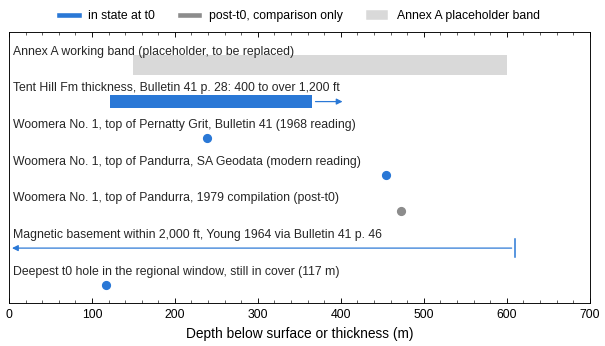

t0   Annex A working band (placeholder, to be replaced): 150 to 600 m
t0   Tent Hill Fm thickness, Bulletin 41 p. 28: 400 to over 1,200 ft: 122 to 366 m
t0   Woomera No. 1, top of Pernatty Grit, Bulletin 41 (1968 reading): 239 m
t0   Woomera No. 1, top of Pandurra, SA Geodata (modern reading): 454 m
post  Woomera No. 1, top of Pandurra, 1979 compilation (post-t0): 472 m
t0   Magnetic basement within 2,000 ft, Young 1964 via Bulletin 41 p. 46: 0 to 610 m
t0   Deepest t0 hole in the regional window, still in cover (117 m): 117 m


In [11]:
deep_win = reg_t0.max_depth_m.max()
items = [   # label, low, high, kind, in_state
    ("Annex A working band (placeholder, to be replaced)", 150, 600, "band", True),
    ("Tent Hill Fm thickness, Bulletin 41 p. 28: 400 to over 1,200 ft", 400 * FT, 1200 * FT, "range_open", True),
    ("Woomera No. 1, top of Pernatty Grit, Bulletin 41 (1968 reading)", 784.5 * FT, None, "point", True),
    ("Woomera No. 1, top of Pandurra, SA Geodata (modern reading)", 454.15, None, "point", True),
    ("Woomera No. 1, top of Pandurra, 1979 compilation (post-t0)", comp_top_pandurra_m, None, "point", False),
    ("Magnetic basement within 2,000 ft, Young 1964 via Bulletin 41 p. 46", 0, 2000 * FT, "upper", True),
    (f"Deepest t0 hole in the regional window, still in cover ({deep_win:.0f} m)", deep_win, None, "point", True),
]
fig, ax = plt.subplots(figsize=(COL15, 3.2))
fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.16)
for i, (lab, lo, hi, kind, ok) in enumerate(items):
    col = "#2a78d6" if ok else "0.55"
    if kind == "band":
        ax.barh(i, hi - lo, left=lo, height=0.55, color="0.85", lw=0)
    elif kind == "range_open":
        ax.barh(i, hi - lo, left=lo, height=0.35, color=col, lw=0)
        ax.annotate("", xy=(hi + 40, i), xytext=(hi, i), arrowprops=dict(arrowstyle="-|>", color=col, lw=0.8))
    elif kind == "upper":
        ax.annotate("", xy=(lo, i), xytext=(hi, i), arrowprops=dict(arrowstyle="-|>", color=col, lw=0.8))
        ax.plot([hi, hi], [i - 0.25, i + 0.25], color=col, lw=1.0)
    else:
        ax.plot(lo, i, "o", color=col, ms=5)
    ax.text(5, i - 0.2, lab, va="bottom", color="0.15")
ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(items) - 0.5, -0.9)
ax.set_xlim(0, 700); ax.set_xlabel("Depth below surface or thickness (m)")
handles = [plt.Line2D([], [], color="#2a78d6", lw=3, label="in state at t0"), plt.Line2D([], [], color="0.55", lw=3, label="post-t0, comparison only"),
           plt.Rectangle((0, 0), 1, 1, color="0.85", label="Annex A placeholder band")]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
fig.savefig(FIG / "wp4_L1_D1_constraint_ladder.png", dpi=300)
plt.show()
for lab, lo, hi, kind, ok in items:
    print(f"{'t0 ' if ok else 'post'}  {lab}: {lo:.0f}" + (f" to {hi:.0f} m" if hi else " m"))


### How to read this figure

Each row is one statement about how thick the cover is, or how deep basement lies, that the Level 1 folder can cite; the horizontal axis is depth or thickness in metres. Blue marks are in state at t0, the grey dot is the 1979 compilation shown only for comparison, and the pale band at the top is the 150 to 600 m placeholder that Annex A asks to have replaced. The Tent Hill Formation bar runs from 122 to 366 m with an arrow because the Bulletin says "over 1,200 ft"; it is a formation thickness, not a depth to basement, and excludes any Cambrian or younger cover. The two Woomera No. 1 dots are the same hole read in 1968 (239 m) and today (454 m). The arrow from 610 m is the aeromagnetic depth statement quoted in the Bulletin: magnetic basement on the Andamooka side lies within 2,000 ft of the surface, an upper bound that closes the band from below. The deepest hole in the window before t0 stopped at 117 m without leaving cover. Read together, the rows say that at t0 the cover at the deposit was bounded above roughly 120 m and below about 610 m, with one measured point 82 km away in the 240 to 450 m range depending on the reading; the placeholder band is consistent with that, and can now be cited rather than assumed.


## Verdict on Level 1

All three basis pieces are on disk and in state. Level 1 is complete on disk, but the frame it supports is a bounded band, not a surface. The sheets show only cover at the deposit. The companion text gives a formation thickness of 122 to over 366 m for the Tent Hill Formation, a period log of the one deep hole within 100 km that puts the base of the Adelaidean cover at 239 m (against 454 m in the modern reading of the same hole), and, quoting the 1962 aeromagnetics, a magnetic basement within 610 m on the Andamooka side. No hole drilled before t0 inside the regional window left the cover; none within 82 km logged anything older than Adelaidean; none within 160 km reached crystalline basement. The 1979 compilation reproduces the modern picks to the metre on the Mount Gunson holes, so the modern export can stand in for later-period comparisons, while the Woomera No. 1 case shows that the period and the modern stratigraphy differ by reinterpretation and the frame must cite the 1968 reading at t0.

For the citation table this means: cover thickness at the deposit, t0 = 120 to 610 m, bounded by the Bulletin's formation thickness and the quoted aeromagnetic depth, with WOOMERA 1 as the single measured point; between-bore variance is not estimable from bores inside the window, because there are none to basement; and the unconformity relief field has one qualitative statement to translate, the Woomera Shale thinning to under 50 ft over the Pernatty Grit high at Mount Gunson. Which reading of WOOMERA 1 the frame carries, and whether the Pandurra Formation counts as cover (as SADME used it in 1979) or basement (as SA Geodata codes it), are rulings for Task 2.
